In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

wind = pd.read_csv("../../data/processed/wind_cleaned.csv")
wind["datetime"] = pd.to_datetime(wind["datetime"])

print(wind.shape)
print(wind.head())
print("\nAnomaly rate:", round(wind["anomaly"].mean() * 100, 2), "%")

(50473, 7)
             datetime  active_power_kw  wind_speed_ms  theoretical_power_kwh  \
0 2018-01-01 00:00:00       380.047791       5.311336             416.328908   
1 2018-01-01 00:10:00       453.769196       5.672167             519.917511   
2 2018-01-01 00:20:00       306.376587       5.216037             390.900016   
3 2018-01-01 00:30:00       419.645905       5.659674             516.127569   
4 2018-01-01 00:40:00       380.650696       5.577941             491.702972   

   wind_direction_deg  power_deficit  anomaly  
0          259.994904      36.281117        0  
1          268.641113      66.148316        0  
2          272.564789      84.523429        0  
3          271.258087      96.481664        0  
4          265.674286     111.052276        0  

Anomaly rate: 10.0 %


In [2]:
anomaly_counts = wind["anomaly"].value_counts().reset_index()
anomaly_counts.columns = ["status", "count"]
anomaly_counts["status"] = anomaly_counts["status"].map({0: "Normal", 1: "Anomaly"})

fig = px.bar(anomaly_counts, x="status", y="count",
             color="status",
             color_discrete_map={"Normal": "#2563eb", "Anomaly": "#ef4444"},
             title="Wind Turbine — Anomaly vs Normal Distribution",
             text="count")
fig.update_layout(showlegend=False)
fig.show()

In [3]:
fig = px.scatter(wind, x="wind_speed_ms", y="active_power_kw",
                 color="anomaly",
                 color_discrete_map={0: "#2563eb", 1: "#ef4444"},
                 title="Wind Turbine — Power Curve (Actual vs Wind Speed)",
                 labels={"wind_speed_ms": "Wind Speed (m/s)",
                         "active_power_kw": "Active Power (kW)",
                         "anomaly": "Anomaly"},
                 opacity=0.4)
fig.show()

In [4]:
fig = px.histogram(wind, x="power_deficit", nbins=60,
                   color="anomaly",
                   color_discrete_map={0: "#2563eb", 1: "#ef4444"},
                   barmode="overlay",
                   title="Wind Turbine — Power Deficit Distribution",
                   labels={"power_deficit": "Power Deficit (kW)", 
                           "anomaly": "Anomaly"},
                   opacity=0.7)
fig.show()

In [5]:
wind["month"] = wind["datetime"].dt.month
wind["month_name"] = wind["datetime"].dt.strftime("%B")

monthly = wind.groupby("month")["anomaly"].mean().reset_index()
monthly["anomaly_rate"] = (monthly["anomaly"] * 100).round(2)
monthly["month_name"] = pd.to_datetime(monthly["month"], format="%m").dt.strftime("%B")

fig = px.bar(monthly, x="month_name", y="anomaly_rate",
             title="Wind Turbine — Monthly Anomaly Rate (%)",
             labels={"month_name": "Month", "anomaly_rate": "Anomaly Rate (%)"},
             color="anomaly_rate",
             color_continuous_scale="Reds")
fig.show()

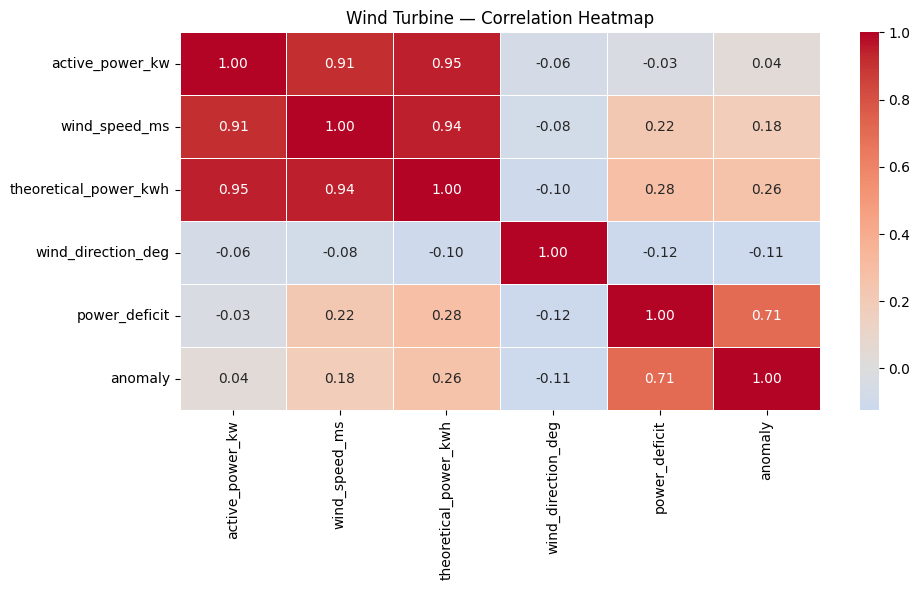

In [6]:
wind_numeric = wind.select_dtypes(include=np.number).drop(columns=["month"])

plt.figure(figsize=(10, 6))
sns.heatmap(wind_numeric.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Wind Turbine — Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../reports/figures/turbine_correlation_heatmap.png", dpi=150)
plt.show()

In [7]:
# Power efficiency ratio
wind["efficiency"] = wind["active_power_kw"] / wind["theoretical_power_kwh"].replace(0, np.nan)
wind["efficiency"] = wind["efficiency"].fillna(0).clip(0, 1)

# Hour and season
wind["hour"] = wind["datetime"].dt.hour
wind["season"] = wind["month"].map({
    12: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
})

print("New features added: efficiency, hour, season")
print(wind[["efficiency", "hour", "season"]].describe())

New features added: efficiency, hour, season
         efficiency          hour        season
count  50473.000000  50473.000000  50473.000000
mean       0.675131     11.518000      1.487647
std        0.387459      6.933414      1.098355
min        0.000000      0.000000      0.000000
25%        0.454784      5.000000      1.000000
50%        0.859382     12.000000      1.000000
75%        0.961041     18.000000      2.000000
max        1.000000     23.000000      3.000000


In [8]:
wind.to_csv("../../data/processed/wind_cleaned.csv", index=False)
print("Saved updated wind CSV with new features.")
print("Final shape:", wind.shape)

Saved updated wind CSV with new features.
Final shape: (50473, 12)
